# 기능 2 — 공격성 탐지 (Aggression Detection)

채팅 메시지의 **공격성 수준을 3단계**로 분류하는 모델입니다.

- **데이터**: AIHub 텍스트 윤리 검증 데이터셋 (`text` + `intensity`)
- **라벨링**: intensity 점수 기반 3단계 — 비공격(0) / 약한공격(1) / 강한공격(2)
- **모델**: KoELECTRA-small(메인) + TF-IDF 로지스틱 회귀(비교 베이스라인)
- **평가**: Accuracy · Macro-F1 · Confusion Matrix (Test 10%)

> **재현성**: Seed=42 / Train:Val:Test = 80:10:10 (Stratified Split)

### 전체 파이프라인
`환경설정 → 데이터 경로 검증 → 데이터 로드·라벨링·정제 → TF-IDF 베이스라인 → KoELECTRA 학습 → 최종 평가(Accuracy·Macro-F1·Confusion Matrix)`

## 0. 환경 설정

필요한 패키지를 설치하고, 원천 데이터셋(`talksets-train-1_aihub.csv`)이 올바른 위치에 있는지 검증합니다.

- 본 프로젝트는 **Google Colab(GPU 런타임)** 기준으로 작성되었습니다.
- 원본 파일은 `talksets-train-1_aihub.csv` 라는 이름으로 노트북과 같은 경로(Colab은 `/content/`)에 둡니다.

In [1]:
# [환경 세팅] 필요한 패키지 설치
# 본 프로젝트의 작업/실행 환경은 Google Colab 기준입니다.
import os
import sys

print("[System] 필수 패키지 설치를 시작합니다...")
!pip install -q torch transformers datasets evaluate accelerate scikit-learn pandas numpy matplotlib seaborn
print("[System] 패키지 설치 완료!")

[System] 필수 패키지 설치를 시작합니다...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
[System] 패키지 설치 완료!


In [2]:
# [로그 기록 시작] 이후 모든 print 출력을 콘솔과 log.txt 에 동시 기록 (재현성/적법성 증빙용)
import sys
import datetime


class _Tee:
    """stdout 출력을 콘솔과 로그 파일에 동시에 기록하는 도우미"""
    def __init__(self, *streams):
        self.streams = streams

    def write(self, data):
        for s in self.streams:
            s.write(data)
            s.flush()

    def flush(self):
        for s in self.streams:
            s.flush()

    def isatty(self):
        # transformers 등 일부 라이브러리가 stdout.isatty()를 호출하므로 지원한다.
        first = self.streams[0] if self.streams else None
        fn = getattr(first, "isatty", None)
        return fn() if callable(fn) else False

    def __getattr__(self, name):
        # write/flush/isatty 외의 속성(fileno, encoding, buffer 등)은 원본 stream에 위임한다.
        return getattr(self.streams[0], name)


# 원본 stdout 보관 (셀 재실행 시 중복 래핑 방지)
if not hasattr(sys, "_orig_stdout"):
    sys._orig_stdout = sys.stdout

# log.txt 새로 쓰기 모드로 열기 (이전 실행 로그는 덮어씀)
_log_file = open("log.txt", "w", encoding="utf-8")
sys.stdout = _Tee(sys._orig_stdout, _log_file)

print("=" * 60)
print("[LOG] 기능 2 - 공격성 탐지(Aggression Detection) 실행 로그")
print(f"[LOG] 기록 시작 시각: {datetime.datetime.now():%Y-%m-%d %H:%M:%S}")
print("[LOG] Seed=42 / Stratified 8:1:1 / 지표: Accuracy, Macro-F1, Confusion Matrix")
print("[LOG] 이후의 모든 진행 상황이 log.txt 에 기록됩니다.")
print("=" * 60)


[LOG] 기능 2 - 공격성 탐지(Aggression Detection) 실행 로그
[LOG] 기록 시작 시각: 2026-06-09 12:04:25
[LOG] Seed=42 / Stratified 8:1:1 / 지표: Accuracy, Macro-F1, Confusion Matrix
[LOG] 이후의 모든 진행 상황이 log.txt 에 기록됩니다.


In [3]:
# 원천 데이터셋 경로 검증
DATA_PATH = "talksets-train-1_aihub.csv"  # 노트북과 같은 경로 (Colab은 /content/)

if not os.path.exists(DATA_PATH):
    print("="*60)
    print(f"[오류] 현재 경로에 '{DATA_PATH}' 파일이 존재하지 않습니다.")
    print("본 기능은 AIHub 텍스트 윤리 검증 데이터셋(talksets-train-1_aihub.csv)을 사용합니다.")
    print("해당 파일을 다운로드한 후, Colab 메인 경로(/content/)에 업로드해 주세요.")
    print("="*60)
    sys.exit(1)
else:
    print(f"[System] '{DATA_PATH}' 데이터셋이 정상적으로 로드되었습니다. 전처리를 시작합니다.")

[System] 'talksets-train-1_aihub.csv' 데이터셋이 정상적으로 로드되었습니다. 전처리를 시작합니다.


## 1. 데이터 전처리

원천 데이터(`talksets-train-1_aihub.csv`, 70,593행)를 읽어 학습용 라벨을 만들고 정제합니다.

- **라벨링 (intensity binning)**: `< 1.0 → 0(비공격)` / `1.0 ~ 1.8 → 1(약한공격)` / `≥ 1.8 → 2(강한공격)`
- **정제**: 결측·공백·중복(text 기준) 제거 → 69,309행
- **다운샘플링 생략**: 클래스 균등화를 하지 않고 원본 규모를 그대로 유지 (분포 0=29,487 / 1=21,995 / 2=17,827)
- 정제 결과를 `aggression_processed_subset.csv` 로 저장하여 이후 학습 셀에서 재사용합니다.

In [4]:
def read_csv_safe(path, **kwargs):
    """인코딩(utf-8/cp949 등)을 자동으로 시도해 CSV를 읽는다.
    AIHub 원본은 CP949, 전처리 후 파일은 UTF-8이라 환경마다 다를 수 있어 모두 대응."""
    import pandas as pd
    last_err = None
    for enc in ("utf-8-sig", "utf-8", "cp949", "euc-kr", "latin1"):
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except UnicodeDecodeError as e:
            last_err = e
    raise last_err

import pandas as pd

print("=== [1단계] 데이터 로드 완료 ===")
# 원본 데이터 로드
df = read_csv_safe("talksets-train-1_aihub.csv")
print(f"전체 데이터 개수: {len(df)}개")

# intensity 점수로 label 컬럼 생성
# 임계치 기준: 1.0 미만 0, 1.8 미만 1, 그 외 2
# (빈 점수(NaN intensity)가 else 2(강한공격)로 잘못 분류되지 않도록 라벨링 전에 결측 제거)
df = df.dropna(subset=['text', 'intensity'])
df['label'] = df['intensity'].apply(lambda x: 0 if x < 1.0 else (1 if x < 1.8 else 2))

print("\n=== [2단계] Intensity Binning 완료 (3단계: 0/1/2) ===")
print("전처리 전 라벨별 데이터 분포:")
print(df['label'].value_counts().sort_index())

# 공백 및 중복 정제
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'] != ""]
df = df.drop_duplicates(subset=['text'])

print(f"\n=== [추가 반영] 공백 및 중복 데이터 정제 완료 ===")
print(f"정제 후 남은 데이터 개수: {len(df)}개")

# 클래스 균등 샘플링을 생략하고 원본 규모를 유지한다.
print(f"\n=== [3단계] 원본 규모 유지 (샘플링 생략) ===")
print(f"최종 실험용 데이터 개수: {len(df)}개")
print("최종 실험용 라벨별 데이터 분포:")
print(df['label'].value_counts().sort_index())

# 파일 저장
df.to_csv("aggression_processed_subset.csv", index=False)
print("\n=== [4단계] 'aggression_processed_subset.csv' 저장 완료 ===")

=== [1단계] 데이터 로드 완료 ===
전체 데이터 개수: 70593개

=== [2단계] Intensity Binning 완료 (3단계: 0/1/2) ===
전처리 전 라벨별 데이터 분포:
label
0    30549
1    22167
2    17877
Name: count, dtype: int64

=== [추가 반영] 공백 및 중복 데이터 정제 완료 ===
정제 후 남은 데이터 개수: 69309개

=== [3단계] 원본 규모 유지 (샘플링 생략) ===
최종 실험용 데이터 개수: 69309개
최종 실험용 라벨별 데이터 분포:
label
0    29487
1    21995
2    17827
Name: count, dtype: int64

=== [4단계] 'aggression_processed_subset.csv' 저장 완료 ===


## 2. 데이터 분할 (8:1:1)

정제 데이터를 **Stratified 8:1:1** 로 나눠 학습/검증/평가에 사용합니다. (seed=42)
- Train 55,447 / Validation 6,931 / Test 6,931
- 여기서 만든 `train_df` / `test_df` 는 이후 베이스라인 비교에서도 재사용합니다.

In [5]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, set_seed
from datasets import Dataset

# Seed 고정
set_seed(42)

# 정제된 데이터 불러오기
df = read_csv_safe("aggression_processed_subset.csv")
df = df.dropna()

print("=== [1] 데이터셋 분포 결과 (정제 데이터 전체 반영) ===")
print(df['label'].value_counts().sort_index())
print("-" * 40)

# 8:1:1 분할 (stratified)
train_df, rest_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(rest_df, test_size=0.5, random_state=42, stratify=rest_df['label'])

print(f"데이터 분할 완료 -> Train: {len(train_df)}개 | Val: {len(val_df)}개 | Test: {len(test_df)}개")

# HuggingFace Dataset 변환
train_dataset = Dataset.from_pandas(train_df.drop(columns=['__index_level_0__'], errors='ignore'))
val_dataset = Dataset.from_pandas(val_df.drop(columns=['__index_level_0__'], errors='ignore'))
test_dataset = Dataset.from_pandas(test_df.drop(columns=['__index_level_0__'], errors='ignore'))


=== [1] 데이터셋 분포 결과 (정제 데이터 전체 반영) ===
label
0    29487
1    21995
2    17827
Name: count, dtype: int64
----------------------------------------
데이터 분할 완료 -> Train: 55447개 | Val: 6931개 | Test: 6931개


## 3. 토큰화 & 모델 로드

KoELECTRA-small 토크나이저로 토큰화하고(max_length=128), 3-class 분류 모델을 불러옵니다.

In [6]:
# 토크나이저 및 모델 세팅
MODEL_NAME = "monologg/koelectra-small-v3-discriminator"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/263k [00:00<?, ?B/s]

Map:   0%|          | 0/55447 [00:00<?, ? examples/s]

Map:   0%|          | 0/6931 [00:00<?, ? examples/s]

Map:   0%|          | 0/6931 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/56.6M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-small-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your d

## 4. 평가지표 & 학습 인자 설정

Accuracy·Macro-F1 지표와 `TrainingArguments`·`Trainer` 를 구성합니다.

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,   # 체크포인트 1개만 유지 (디스크 정리)
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42,
    load_best_model_at_end=True,   # validation 성능이 가장 좋았던 epoch 모델을 최종 채택
    metric_for_best_model="f1",   # 선택 기준 = validation Macro-F1
    greater_is_better=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)


## 5. 학습 & 최종 평가 (Test)

Train + Validation 으로 학습한 뒤, 학습 종료 후 **Test 로 1회만** 평가합니다.
Accuracy·Macro-F1·Confusion Matrix 와 기능3 연동용 Binary 지표를 출력합니다.

> 누출 방지: 학습은 Train+Val만, Test는 마지막 평가에만 사용.


KoELECTRA-small 학습 시작...


model.safetensors:   0%|          | 0.00/56.5M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.789768,0.788008,0.622565,0.579033
2,0.749276,0.763930,0.640023,0.592883
3,0.724379,0.770722,0.642043,0.604349


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== 최종 평가 (Test 10%) ===


[3-Class 정밀 분류 리포트 (Test Dataset)]
              precision    recall  f1-score   support

      비공격(0)       0.74      0.88      0.80      2949
     약한공격(1)       0.51      0.51      0.51      2200
     강한공격(2)       0.61      0.41      0.50      1782

    accuracy                           0.64      6931
   macro avg       0.62      0.60      0.60      6931
weighted avg       0.63      0.64      0.63      6931

----------------------------------------

=== 기능 3 연동용 Binary 성능 지표 (공격 vs 비공격) ===
Binary Accuracy : 0.8156
Binary Precision: 0.8956
Binary Recall   : 0.7687
Binary F1-Score : 0.8273
----------------------------------------
[저장] confusion_matrix_aggression.png -> 작업폴더  (드라이브 저장 셀에서 feature2 폴더로 복사됨)


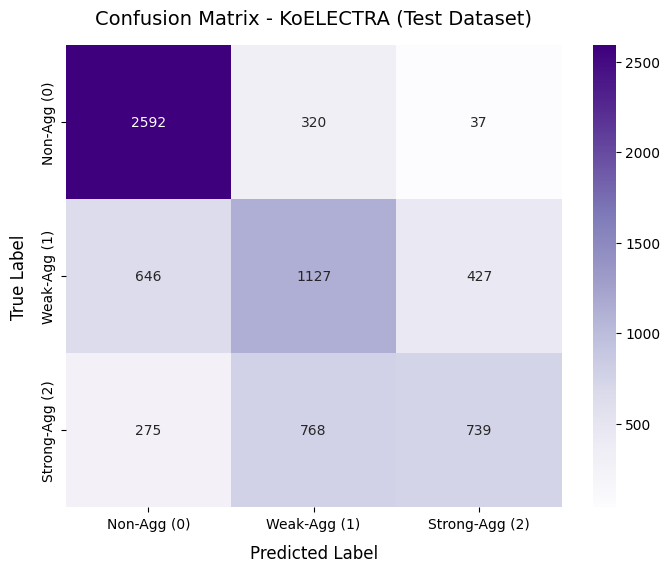

[저장] result.txt (KoELECTRA 최종 성능) -> 작업폴더  (드라이브 저장 셀에서 feature2 폴더로 복사됨)


In [8]:
print("\nKoELECTRA-small 학습 시작...")
trainer.train()

print("\n" + "="*50)
print("=== 최종 평가 (Test 10%) ===")
print("="*50)

test_predictions = trainer.predict(tokenized_test)
y_pred = np.argmax(test_predictions.predictions, axis=-1)
y_true = test_predictions.label_ids

print("[3-Class 정밀 분류 리포트 (Test Dataset)]")
print(classification_report(y_true, y_pred, target_names=['비공격(0)', '약한공격(1)', '강한공격(2)']))
print("-" * 40)

# Binary 지표 산출
y_true_binary = np.where(y_true == 0, 0, 1)
y_pred_binary = np.where(y_pred == 0, 0, 1)

print("\n=== 기능 3 연동용 Binary 성능 지표 (공격 vs 비공격) ===")
print(f"Binary Accuracy : {accuracy_score(y_true_binary, y_pred_binary):.4f}")
print(f"Binary Precision: {precision_score(y_true_binary, y_pred_binary):.4f}")
print(f"Binary Recall   : {recall_score(y_true_binary, y_pred_binary):.4f}")
print(f"Binary F1-Score : {f1_score(y_true_binary, y_pred_binary):.4f}")
print("-" * 40)

# Confusion Matrix 시각화 + PNG 저장 (기능1과 동일하게 자동 생성)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Non-Agg (0)', 'Weak-Agg (1)', 'Strong-Agg (2)'],
            yticklabels=['Non-Agg (0)', 'Weak-Agg (1)', 'Strong-Agg (2)'])
plt.title('Confusion Matrix - KoELECTRA (Test Dataset)', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.savefig('confusion_matrix_aggression.png', dpi=300, bbox_inches='tight')
print("[저장] confusion_matrix_aggression.png -> 작업폴더  (드라이브 저장 셀에서 feature2 폴더로 복사됨)")
plt.show()

# === result.txt 자동 생성 (KoELECTRA 최종 Test 성능) ===
# 주의: 아래 베이스라인 셀이 y_pred 를 덮어쓰므로, 메인 모델 성능은 반드시 여기서 기록한다.
import datetime
_acc = accuracy_score(y_true, y_pred)
_mf1 = f1_score(y_true, y_pred, average='macro')
_rep = classification_report(y_true, y_pred, target_names=['비공격(0)', '약한공격(1)', '강한공격(2)'], digits=4, output_dict=True)
_result2_text = "\n".join([
    "=" * 60,
    "[기능 2 - 공격성 탐지 (Aggression Detection)] 재현성 & 결과",
    "=" * 60,
    "",
    "[데이터셋]",
    "- 출처   : AIHub 텍스트 윤리 검증 데이터셋 (talksets-train-1_aihub.csv)",
    "- 라벨링 : intensity binning ( <1.0 → 0(비공격) / 1.0~1.8 → 1(약한공격) / ≥1.8 → 2(강한공격) )",
    "- 정제   : 결측/공백/중복 제거 (클래스 샘플링 생략, 원본 규모 유지)",
    f"- 분할   : Stratified 80:10:10  (Train {len(train_df)} / Val {len(val_df)} / Test {len(test_df)})",
    "",
    "[재현성]",
    "- Seed : 42  (transformers set_seed(42) + random_state=42)",
    "",
    "[모델]",
    "- KoELECTRA-small (monologg/koelectra-small-v3-discriminator), 3-class",
    "- 선택 : load_best_model_at_end=True (Validation Macro-F1 기준 best epoch)",
    "",
    f"[최종 성능] (Test {len(y_true)}개, 3-class)",
    f"- Accuracy : {_acc:.4f}",
    f"- Macro-F1 : {_mf1:.4f}",
    f"- 비공격(0)   : precision {_rep['비공격(0)']['precision']:.4f} / recall {_rep['비공격(0)']['recall']:.4f} / f1 {_rep['비공격(0)']['f1-score']:.4f}",
    f"- 약한공격(1) : precision {_rep['약한공격(1)']['precision']:.4f} / recall {_rep['약한공격(1)']['recall']:.4f} / f1 {_rep['약한공격(1)']['f1-score']:.4f}",
    f"- 강한공격(2) : precision {_rep['강한공격(2)']['precision']:.4f} / recall {_rep['강한공격(2)']['recall']:.4f} / f1 {_rep['강한공격(2)']['f1-score']:.4f}",
    f"- Confusion Matrix(행=실제,열=예측) : {cm.tolist()}  (이미지: confusion_matrix_aggression.png)",
    "",
    "[기능 3 연동용 Binary 지표] (공격 1·2 vs 비공격 0)",
    f"- Binary Accuracy : {accuracy_score(y_true_binary, y_pred_binary):.4f}",
    f"- Binary Precision: {precision_score(y_true_binary, y_pred_binary):.4f}",
    f"- Binary Recall   : {recall_score(y_true_binary, y_pred_binary):.4f}",
    f"- Binary F1-Score : {f1_score(y_true_binary, y_pred_binary):.4f}",
    "",
    "[적법성 확인]",
    "- 학습  : Train + Validation 만 사용 (Validation Macro-F1 기준 best epoch 채택)",
    "- 테스트 : 학습 종료 후 Test 로 1회만 측정 (테스트셋 누출 없음)",
    f"- 기록 시각 : {datetime.datetime.now():%Y-%m-%d %H:%M:%S}",
    "",
])
with open("result.txt", "w", encoding="utf-8") as _f:
    _f.write(_result2_text)
print("[저장] result.txt (KoELECTRA 최종 성능) -> 작업폴더  (드라이브 저장 셀에서 feature2 폴더로 복사됨)")

## 6. 추론 예시

임의 문장 10개에 대한 모델 예측을 확인합니다.

In [9]:
# 임의 문장 10개 추론 예시
additional_comments = [
    "아 진짜 짜증나네 일 똑바로 안 하냐? 죽고 싶냐 진짜",
    "와 미친... 이거 진짜 대박이다 소름 돋았음 ㅠㅠ",
    "적당히 좀 하세요 진짜 짜증나게 만드네 ㅡㅡ",
    "야 이 개새끼야 대가리 총 맞았냐? 걍 뒤져라",
    "그쪽 의견도 알겠는데 제 생각은 좀 달라요.",
    "저 지금 알바 중이라 확인이 늦었어요 ㅠㅠ 죄송해요",
    "와 피피티 퀄리티 진짜 미쳤다!! 너무 고생하셨어요!! 😭👍",
    "그쪽은 저번 주부터 피드백도 없고... 참여 안 하시는 걸로 알게요 ^^",
    "제출 기한이 오늘 자정까지인데, 혹시 자료조사는 언제쯤 주실 수 있을까요?",
    "자료조사 다 했다고 보내신 게 고작 이건가요? 초등학생도 안 하겠네"
]

print("\n=== 임의 문장 10개 추론 예시 ===")
model.eval()
for i, test_comment in enumerate(additional_comments, 1):
    inputs = tokenizer(test_comment, return_tensors="pt", padding=True, truncation=True, max_length=128).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
        pred_label = torch.argmax(outputs.logits, dim=-1).item()
    label_dict = {0: "비공격 (0)", 1: "약한 공격 (1)", 2: "강한 공격 (2)"}
    print(f"예시 {i}) 입력 댓글: \"{test_comment}\" -> 예측 결과: {label_dict[pred_label]}")


=== 임의 문장 10개 추론 예시 ===
예시 1) 입력 댓글: "아 진짜 짜증나네 일 똑바로 안 하냐? 죽고 싶냐 진짜" -> 예측 결과: 강한 공격 (2)
예시 2) 입력 댓글: "와 미친... 이거 진짜 대박이다 소름 돋았음 ㅠㅠ" -> 예측 결과: 비공격 (0)
예시 3) 입력 댓글: "적당히 좀 하세요 진짜 짜증나게 만드네 ㅡㅡ" -> 예측 결과: 약한 공격 (1)
예시 4) 입력 댓글: "야 이 개새끼야 대가리 총 맞았냐? 걍 뒤져라" -> 예측 결과: 강한 공격 (2)
예시 5) 입력 댓글: "그쪽 의견도 알겠는데 제 생각은 좀 달라요." -> 예측 결과: 비공격 (0)
예시 6) 입력 댓글: "저 지금 알바 중이라 확인이 늦었어요 ㅠㅠ 죄송해요" -> 예측 결과: 비공격 (0)
예시 7) 입력 댓글: "와 피피티 퀄리티 진짜 미쳤다!! 너무 고생하셨어요!! 😭👍" -> 예측 결과: 비공격 (0)
예시 8) 입력 댓글: "그쪽은 저번 주부터 피드백도 없고... 참여 안 하시는 걸로 알게요 ^^" -> 예측 결과: 비공격 (0)
예시 9) 입력 댓글: "제출 기한이 오늘 자정까지인데, 혹시 자료조사는 언제쯤 주실 수 있을까요?" -> 예측 결과: 비공격 (0)
예시 10) 입력 댓글: "자료조사 다 했다고 보내신 게 고작 이건가요? 초등학생도 안 하겠네" -> 예측 결과: 약한 공격 (1)


## 7. TF-IDF + 로지스틱 회귀 (비교 베이스라인)

딥러닝 모델과 성능을 비교하기 위한 **가벼운 베이스라인**입니다.

- TF-IDF(max_features=5000)로 문장을 벡터화한 뒤 로지스틱 회귀로 3단계 분류
- 위 KoELECTRA 셀과 **동일한 `train_df` / `test_df` (8:1:1 분할)** 로 학습·평가하여 공정하게 비교합니다.

In [10]:
# 비교 베이스라인: TF-IDF + 로지스틱 회귀
# 위 KoELECTRA 셀에서 만든 동일한 train_df / test_df 를 그대로 사용한다.
# (이 셀은 반드시 위의 KoELECTRA 셀을 먼저 실행한 뒤 돌려야 한다.)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

print("=== 베이스라인: TF-IDF + 로지스틱 회귀 (KoELECTRA와 동일 8:1:1 분할) ===")

# KoELECTRA 셀에서 생성된 동일 분할 재사용
X_train, y_train = train_df["text"], train_df["label"]
X_test,  y_test  = test_df["text"],  test_df["label"]
print(f"Train: {len(X_train)}개 | Test: {len(X_test)}개 (KoELECTRA와 동일)")

# TF-IDF 변환 (train 으로만 fit)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 학습
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# 평가 (KoELECTRA와 동일한 Test 로 측정)
y_pred = lr_model.predict(X_test_tfidf)
print()
print(f"[베이스라인 최종 성적 / Test {len(y_test)}개]")
print(f"정확도(Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro-F1       : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(classification_report(y_test, y_pred, target_names=['비공격(0)', '약한공격(1)', '강한공격(2)']))

=== 베이스라인: TF-IDF + 로지스틱 회귀 (KoELECTRA와 동일 8:1:1 분할) ===
Train: 55447개 | Test: 6931개 (KoELECTRA와 동일)

[베이스라인 최종 성적 / Test 6931개]
정확도(Accuracy): 0.5501
Macro-F1       : 0.5022
              precision    recall  f1-score   support

      비공격(0)       0.60      0.80      0.69      2949
     약한공격(1)       0.48      0.42      0.45      2200
     강한공격(2)       0.48      0.30      0.37      1782

    accuracy                           0.55      6931
   macro avg       0.52      0.51      0.50      6931
weighted avg       0.53      0.55      0.53      6931



In [11]:
# [로그 기록 종료] log.txt 마무리 및 파일 닫기 (모든 셀 실행 후 마지막에 1회 실행)
import sys
import datetime

print("=" * 60)
print(f"[LOG] 기록 종료 시각: {datetime.datetime.now():%Y-%m-%d %H:%M:%S}")
print("[LOG] 모든 실행이 정상적으로 완료되었습니다.")
print("=" * 60)

# stdout 을 원래대로 복구하고 로그 파일을 안전하게 닫는다
if hasattr(sys, "_orig_stdout"):
    sys.stdout = sys._orig_stdout
try:
    _log_file.close()
except Exception:
    pass

print("[System] 'log.txt' 저장 완료!")


[LOG] 기록 종료 시각: 2026-06-09 12:10:51
[LOG] 모든 실행이 정상적으로 완료되었습니다.
[System] 'log.txt' 저장 완료!


## 8. 구글 드라이브에 저장 (기능 3 연동용)

기능 2의 모든 산출물을 **내 드라이브의 `MyDrive/feature2/` 한 폴더**에 모아 저장합니다.
기능 1·2·3을 각각 다른 Colab 세션에서 실행하므로, 공유 저장소인 드라이브에 저장해야 기능 3이 연동됩니다.
**런타임을 닫기 전에 이 셀을 실행하세요.**

`MyDrive/feature2/` 에 저장되는 것:
- `chaeon_feature2_model/` ← KoELECTRA 모델 + 토크나이저
- `result.txt` ← Test 기준 최종 지표(Accuracy·Macro-F1·Binary) **자동 생성** (최종 평가 셀에서 작성)
- `confusion_matrix_aggression.png` ← Test Confusion Matrix(3×3) **자동 생성** (최종 평가 셀에서 작성)
- `log.txt` ← 실행 로그 (작업폴더에서 복사)

> 기능 3 통합 노트북은 이 `MyDrive/feature2/` 경로에서 모델을 불러옵니다.

In [13]:
# [기능 3 연동 + 산출물 정리] KoELECTRA 모델·result·log·confusion matrix 를 MyDrive/feature2/ 한 폴더에 모아 저장
import os, shutil
from google.colab import drive

drive.mount('/content/drive')
F2_DIR = '/content/drive/MyDrive/feature2'   # 기능2 산출물 전용 폴더 (모델+result+log 한 곳)
os.makedirs(F2_DIR, exist_ok=True)

# 1) KoELECTRA 모델 + 토크나이저 -> feature2 폴더
dst = os.path.join(F2_DIR, 'chaeon_feature2_model')
trainer.save_model(dst)          # 모델 가중치 + config
tokenizer.save_pretrained(dst)   # 토크나이저
print('[저장] KoELECTRA 모델 ->', dst)
print('  내용:', os.listdir(dst))

# 2) result.txt 복사 (최종 평가 셀에서 KoELECTRA 성능으로 이미 작성됨)
if os.path.exists("result.txt"):
    shutil.copy("result.txt", os.path.join(F2_DIR, "result.txt"))
    print('[저장] result.txt ->', F2_DIR)
else:
    print('[건너뜀] result.txt 가 작업폴더에 없습니다. 최종 평가 셀(5.학습&최종평가)을 먼저 실행하세요.')

# 3) confusion_matrix_aggression.png 복사 (최종 평가 셀에서 자동 생성됨)
if os.path.exists("confusion_matrix_aggression.png"):
    shutil.copy("confusion_matrix_aggression.png", os.path.join(F2_DIR, "confusion_matrix_aggression.png"))
    print('[저장] confusion_matrix_aggression.png ->', F2_DIR)
else:
    print('[건너뜀] confusion_matrix_aggression.png 가 없습니다. 최종 평가 셀(5.학습&최종평가)을 먼저 실행하세요.')

# 4) log.txt 복사 (로그 종료 셀에서 이미 작성·닫힘)
if os.path.exists("log.txt"):
    shutil.copy("log.txt", os.path.join(F2_DIR, "log.txt"))
    print('[저장] log.txt ->', F2_DIR)

# 5) 저장 검증 — 기능 3에서 그대로 불러올 수 있는지 확인
weights_ok = any(os.path.exists(os.path.join(dst, w))
                 for w in ['model.safetensors', 'pytorch_model.bin'])
assert weights_ok, '[실패] 모델 가중치가 ' + dst + ' 에 없습니다. trainer.train() 이 정상 완료됐는지 확인하세요.'
print('[검증 완료] 기능 2 산출물(모델+result+log+confusion matrix) 저장 OK ->', F2_DIR)

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[저장] KoELECTRA 모델 -> /content/drive/MyDrive/feature2/chaeon_feature2_model
  내용: ['config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json']
[저장] result.txt -> /content/drive/MyDrive/feature2
[저장] confusion_matrix_aggression.png -> /content/drive/MyDrive/feature2
[저장] log.txt -> /content/drive/MyDrive/feature2
[검증 완료] 기능 2 산출물(모델+result+log+confusion matrix) 저장 OK -> /content/drive/MyDrive/feature2
